# GPM Data Engineer - Case Study
## MICHAEL VENTURA

<p>transform the data, build a data model, and visualize the metrics you think matter most. The goal is to understand your thought process and approach, so polished formatting and "pretty" visuals are not what we're grading. We care far more about how you reason through the data, structure your model, and decide what's worth surfacing than about pixel-perfect dashboards.</p>

###Setting Environment

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# Load the Excel file and get all sheet names
excel_file = '/content/CRM Data Set - Case Study.xlsx'
xls_df = pd.ExcelFile(excel_file)
sheet_names = xls_df.sheet_names

### EDA Process

#### Loading and analyzing all sheets


In [79]:
print(f"Sheets found: {sheet_names}")

sheets = {}
for sheet in sheet_names:
    sheets[sheet] = pd.read_excel(excel_file, sheet_name=sheet)
    print(f"\n >> {sheet} - {len(sheets[sheet])} rows, {len(sheets[sheet].columns)} columns")
    print(f"\nColumns: {sheets[sheet].columns.tolist()}")

    if sheet in sheets:
      sheet_df = sheets[sheet]
      print(f"\n{sheet_df}: {len(sheet_df)}")
      sheet_df.head()

      print(f"\n{sheet} Original Shape: {sheet_df.shape}\n")
      print(f"\n{sheet} Info: {sheet_df.info()}\n")
      print(f"\n{sheet} Describe: \n{sheet_df.describe()}\n")

      print("=" * 100)

Sheets found: ['Deals', 'Activities', 'Stages', 'Pipeline', 'Organizations']

 >> Deals - 9756 rows, 16 columns

Columns: ['ID', 'Title', 'Value', 'Org ID', 'Stage ID', 'Currency', 'Add time', 'Update time', 'Status', 'Lost reason', 'Close time', 'Pipeline ID', 'Won time', 'Lost time', 'Stage change time', 'Is deleted']

         ID                  Title     Value  Org ID  Stage ID Currency  \
0        42  Booking Platform Lead    504.40    17.0       134      USD   
1        47  Booking Platform Lead     98.69    17.0       134      USD   
2        56  Booking Platform Lead    648.76    17.0       110      USD   
3        57          Web Form Lead      0.00    17.0       111      USD   
4        63          Web Form Lead  12608.97    17.0       134      USD   
...     ...                    ...       ...     ...       ...      ...   
9751  16262          Web Form Lead      0.00    15.0       110      USD   
9752  16263            Direct Lead      0.00   474.0       110      USD   
97

#### Checking for duplicities

In [80]:
for sheet in sheet_names:
    print(f"\n >> Duplicate {sheet} ID: {sheets[sheet]['ID'].duplicated().sum()}")
    columns = sheets[sheet].columns.tolist()

    if 'Name' in columns:
        print(f"\n >> Duplicate {sheet} Name: {sheets[sheet]['Name'].duplicated().sum()}")

    if 'Title' in columns:
        print(f"\n >> Duplicate {sheet} Title: {sheets[sheet]['Title'].duplicated().sum()}")

    if 'Subject' in columns:
        print(f"\n >> Duplicate {sheet} Subject: {sheets[sheet]['Subject'].duplicated().sum()}\n")

    print("=" * 100)



 >> Duplicate Deals ID: 0

 >> Duplicate Deals Title: 9752

 >> Duplicate Activities ID: 0

 >> Duplicate Activities Subject: 5859


 >> Duplicate Stages ID: 0

 >> Duplicate Stages Name: 29

 >> Duplicate Pipeline ID: 0

 >> Duplicate Pipeline Name: 0

 >> Duplicate Organizations ID: 0

 >> Duplicate Organizations Name: 0


#### Referential Integrity

In [37]:
deals_orgs = sheets['Deals']['Org ID'].dropna().unique()
missing_orgs = [o for o in deals_orgs if o not in sheets['Organizations']['ID'].values]
print(f"\nDeals with Org ID not in orgs table: {len(missing_orgs)}")

deals_pipelines = sheets['Deals']['Pipeline ID'].unique()
missing_pipes = [p for p in deals_pipelines if p not in sheets['Pipeline']['ID'].values]
print(f"\nDeals with Pipeline ID not in pipeline table: {len(missing_pipes)}")

deals_stages = sheets['Deals']['Stage ID'].unique()
missing_stages = [s for s in deals_stages if s not in sheets['Stages']['ID'].values]
print(f"\nDeals with Stage ID not in stages table: {len(missing_stages)}\n")



Deals with Org ID not in orgs table: 1

Deals with Pipeline ID not in pipeline table: 0

Deals with Stage ID not in stages table: 0



#### Deals Value Distribution


=== VALUE DISTRIBUTION ===
Zero value deals: 6232 (63.9%)
Positive value deals: 3524

Value statistics (positive only):
count     3524.000000
mean      3684.459296
std       3243.210669
min         22.760000
25%       1316.507500
50%       2910.750000
75%       4765.250000
max      30207.120000
Name: Value, dtype: float64

=== VALUE BY STATUS ===
        count         sum         mean    median
Status                                          
lost     3571  2462102.04   689.471308     0.000
open     3105  2398322.50   772.406602     0.000
won      3080  8123610.02  2637.535721  1741.025


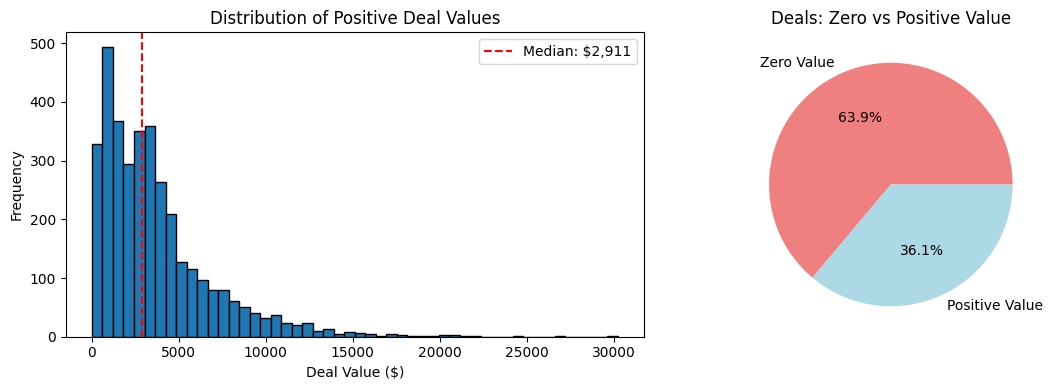

In [38]:
# Value distribution analysis
print("=== VALUE DISTRIBUTION ===")
print(f"Zero value deals: {(sheets['Deals']['Value'] == 0).sum()} ({((sheets['Deals']['Value'] == 0).sum()/len(sheets['Deals']))*100:.1f}%)")
print(f"Positive value deals: {(sheets['Deals']['Value'] > 0).sum()}")
print(f"\nValue statistics (positive only):")
positive_values = sheets['Deals'][sheets['Deals']['Value'] > 0]['Value']
print(positive_values.describe())

#Value by status
print("\n=== VALUE BY STATUS ===")
value_by_status = sheets['Deals'].groupby('Status')['Value'].agg(['count', 'sum', 'mean', 'median'])
print(value_by_status)

#Visualize the split
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogram of all values (log scale due to zeros)
sheets['Deals']['Value_log'] = np.log1p(sheets['Deals']['Value'])
axes[0].hist(sheets['Deals'][sheets['Deals']['Value'] > 0]['Value'], bins=50, edgecolor='black')
axes[0].set_xlabel('Deal Value ($)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Positive Deal Values')
axes[0].axvline(positive_values.median(), color='red', linestyle='--', label=f'Median: ${positive_values.median():,.0f}')
axes[0].legend()

# Pie chart of zero vs non-zero
zero_count = (sheets['Deals']['Value'] == 0).sum()
non_zero_count = (deals['Value'] > 0).sum()
axes[1].pie([zero_count, non_zero_count], labels=['Zero Value', 'Positive Value'],
            autopct='%1.1f%%', colors=['lightcoral', 'lightblue'])
axes[1].set_title('Deals: Zero vs Positive Value')

plt.tight_layout()
plt.show()

#### Pipeline funnel Analysis

=== PIPELINE 19 FUNNEL (General Inquiry) ===
            Stage  Count  Conversion_Rate  Drop_off  Drop_off_Pct
          Lead In    811            100.0       0.0           NaN
Contact Attempted     21              2.6     790.0          97.4
     Contact Made    509             62.8     488.0        2323.8
        Qualified    194             23.9     315.0          61.9
    Proposal Sent    241             29.7      47.0          24.2
      Negotiation     21              2.6     220.0          91.3
 Decision Pending     20              2.5       1.0           4.8
Awaiting Response      5              0.6      15.0          75.0
       Closed Won    366             45.1     361.0        7220.0
      Closed Lost   1702            209.9    1336.0         365.0


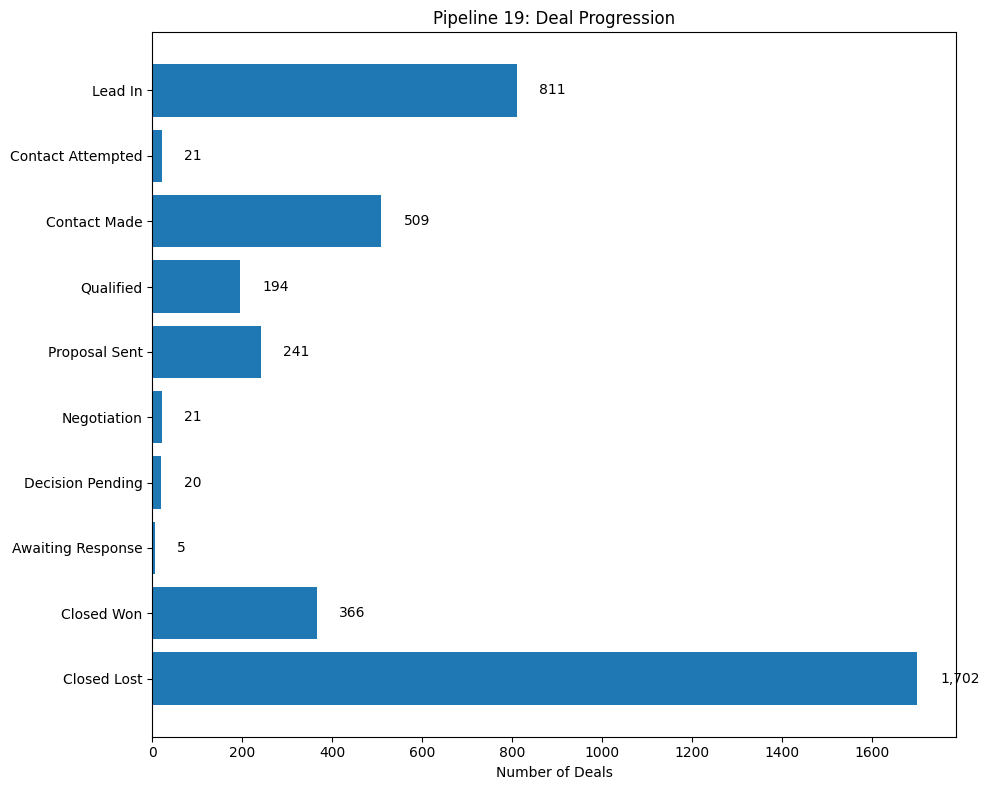


=== WIN RATES BY PIPELINE ===
Pipeline_Name
Auto-Renewal       79.1
General Inquiry    11.5
Maintenance         0.0
Outbound Sales     66.7
Renewal            35.8
Name: Status, dtype: float64


In [56]:
#Map stage names to deals
stage_map = sheets['Stages'].set_index('ID')['Name'].to_dict()
pipeline_map = sheets['Pipeline'].set_index('ID')['Name'].to_dict()

sheets['Deals']['Stage_Name'] = sheets['Deals']['Stage ID'].map(stage_map)
sheets['Deals']['Pipeline_Name'] = sheets['Deals']['Pipeline ID'].map(pipeline_map)

#Create funnel for main pipeline (Pipeline 19 - General Inquiry)
pipeline_19_deals = sheets['Deals'][sheets['Deals']['Pipeline ID'] == 19]
stage_order = sheets['Stages'][sheets['Stages']['Pipeline ID'] == 19].sort_values('Order nr')['Name'].tolist()

#Count deals at each stage
funnel_data = []
for stage in stage_order:
    count = pipeline_19_deals[pipeline_19_deals['Stage_Name'] == stage].shape[0]
    funnel_data.append({'Stage': stage, 'Count': count})

funnel_df = pd.DataFrame(funnel_data)

# Calculate conversion rates
funnel_df['Conversion_Rate'] = (funnel_df['Count'] / funnel_df['Count'].iloc[0] * 100).round(1)
funnel_df['Drop_off'] = funnel_df['Count'].diff().fillna(0).abs()
funnel_df['Drop_off_Pct'] = (funnel_df['Drop_off'] / funnel_df['Count'].shift(1) * 100).round(1)

print("=== PIPELINE 19 FUNNEL (General Inquiry) ===")
print(funnel_df.to_string(index=False))

# Visualize funnel
fig, ax = plt.subplots(figsize=(10, 8))
y_pos = np.arange(len(funnel_df))

bars = ax.barh(y_pos, funnel_df['Count'])
ax.set_yticks(y_pos)
ax.set_yticklabels(funnel_df['Stage'])
ax.set_xlabel('Number of Deals')
ax.set_title('Pipeline 19: Deal Progression')
ax.invert_yaxis()

# Add value labels
for i, (bar, count) in enumerate(zip(bars, funnel_df['Count'])):
    ax.text(bar.get_width() + 50, bar.get_y() + bar.get_height()/2,
            f'{count:,}', ha='left', va='center')

plt.tight_layout()
plt.show()

# 3.5 Compare win rates across pipelines
print("\n=== WIN RATES BY PIPELINE ===")
win_rates = sheets['Deals'].groupby('Pipeline_Name')['Status'].apply(
    lambda x: (x == 'won').sum() / len(x) * 100
).round(1)
print(win_rates)

#### End of Analysis

=== CYCLE TIME ANALYSIS ===
Average days to close (all closed deals): 29.5
Median days to close: 19.0

Won deals avg: 28.7 days
Lost deals avg: 30.1 days


/tmp/ipykernel_3075/20318174.py:30: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot([won_days.dropna(), lost_days.dropna()], labels=['Won', 'Lost'])


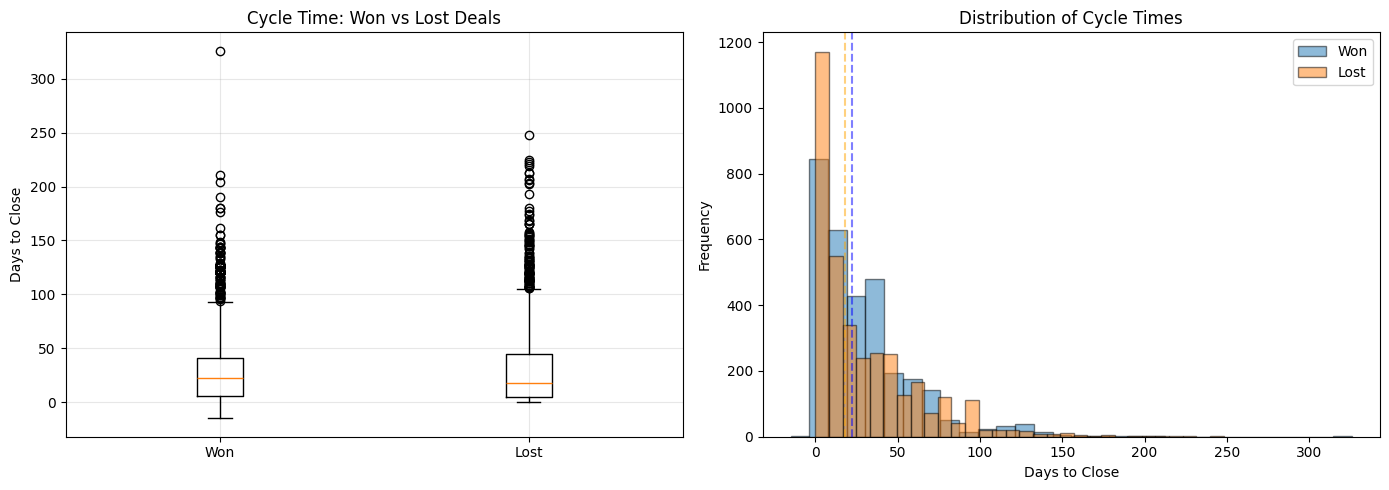


=== MONTHLY TRENDS ===
                Median_Cycle_Days  Win_Rate
Add_Month                                  
2025-12   2026-01-09 00:40:34.000      69.8
2026-01   2026-02-06 16:42:05.000      18.3
2026-02   2026-02-28 18:27:04.000      32.4
2026-03   2026-03-28 16:19:38.500      23.0
2026-04   2026-04-23 19:30:53.000      13.5
2026-05   2026-05-07 15:06:06.500      23.3


In [59]:
# Calculate cycle times
sheets['Deals']['Add_time'] = pd.to_datetime(sheets['Deals']['Add time'])
sheets['Deals']['Close_time'] = pd.to_datetime(sheets['Deals']['Close time'])
sheets['Deals']['Won_time'] = pd.to_datetime(sheets['Deals']['Won time'])
sheets['Deals']['Lost_time'] = pd.to_datetime(sheets['Deals']['Lost time'])

# Only calculate for closed deals
closed_deals = sheets['Deals'][sheets['Deals']['Status'].isin(['won', 'lost'])].copy()
closed_deals['Days_to_close'] = (closed_deals['Close_time'] - closed_deals['Add_time']).dt.days
closed_deals['Days_to_decision'] = np.where(
    closed_deals['Status'] == 'won',
    (closed_deals['Won_time'] - closed_deals['Add_time']).dt.days,
    (closed_deals['Lost_time'] - closed_deals['Add_time']).dt.days
)

print("=== CYCLE TIME ANALYSIS ===")
print(f"Average days to close (all closed deals): {closed_deals['Days_to_close'].mean():.1f}")
print(f"Median days to close: {closed_deals['Days_to_close'].median():.1f}")
print(f"\nWon deals avg: {closed_deals[closed_deals['Status']=='won']['Days_to_close'].mean():.1f} days")
print(f"Lost deals avg: {closed_deals[closed_deals['Status']=='lost']['Days_to_close'].mean():.1f} days")

# Time distribution by status
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Box plot comparison
won_days = closed_deals[closed_deals['Status']=='won']['Days_to_close']
lost_days = closed_deals[closed_deals['Status']=='lost']['Days_to_close']
axes[0].boxplot([won_days.dropna(), lost_days.dropna()], labels=['Won', 'Lost'])
axes[0].set_ylabel('Days to Close')
axes[0].set_title('Cycle Time: Won vs Lost Deals')
axes[0].grid(True, alpha=0.3)

# Histogram
axes[1].hist(won_days.dropna(), bins=30, alpha=0.5, label='Won', edgecolor='black')
axes[1].hist(lost_days.dropna(), bins=30, alpha=0.5, label='Lost', edgecolor='black')
axes[1].set_xlabel('Days to Close')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Distribution of Cycle Times')
axes[1].legend()
axes[1].axvline(won_days.median(), color='blue', linestyle='--', alpha=0.5)
axes[1].axvline(lost_days.median(), color='orange', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# Time trend analysis
sheets['Deals']['Add_Month'] = sheets['Deals']['Add_time'].dt.to_period('M')
monthly_metrics = sheets['Deals'][sheets['Deals']['Status'].isin(['won', 'lost'])].groupby('Add_Month').agg({
    'Close time': 'median',
    'Status': lambda x: (x == 'won').sum() / len(x) * 100
}).round(1)
monthly_metrics.columns = ['Median_Cycle_Days', 'Win_Rate']
print("\n=== MONTHLY TRENDS ===")
print(monthly_metrics.tail(6))

#### Lost Deal Check

=== LOST REASON ANALYSIS ===
                                  Count  Total_Value_Lost  Avg_Value
Lost reason clean                                                   
Switched to competitor             1048         442543.76     422.27
Looking for short-term stay only    872         394877.55     452.84
Lifestyle change                    560         735382.60    1313.18
Taking a break from boating         428         260304.14     608.19
Boat size not supported             168         152211.48     906.02
Unqualified lead                     69          37957.93     550.11
Price too high                       56          61670.94    1101.27
Sold boat                            56          35006.44     625.11
Spam / fake lead                     43          68535.84    1593.86
Existing customer                    42          26669.80     635.00

=== LOST REASONS BY PIPELINE ===
Lost reason clean      Boat size not supported  Chose a different marina  \
Title                            

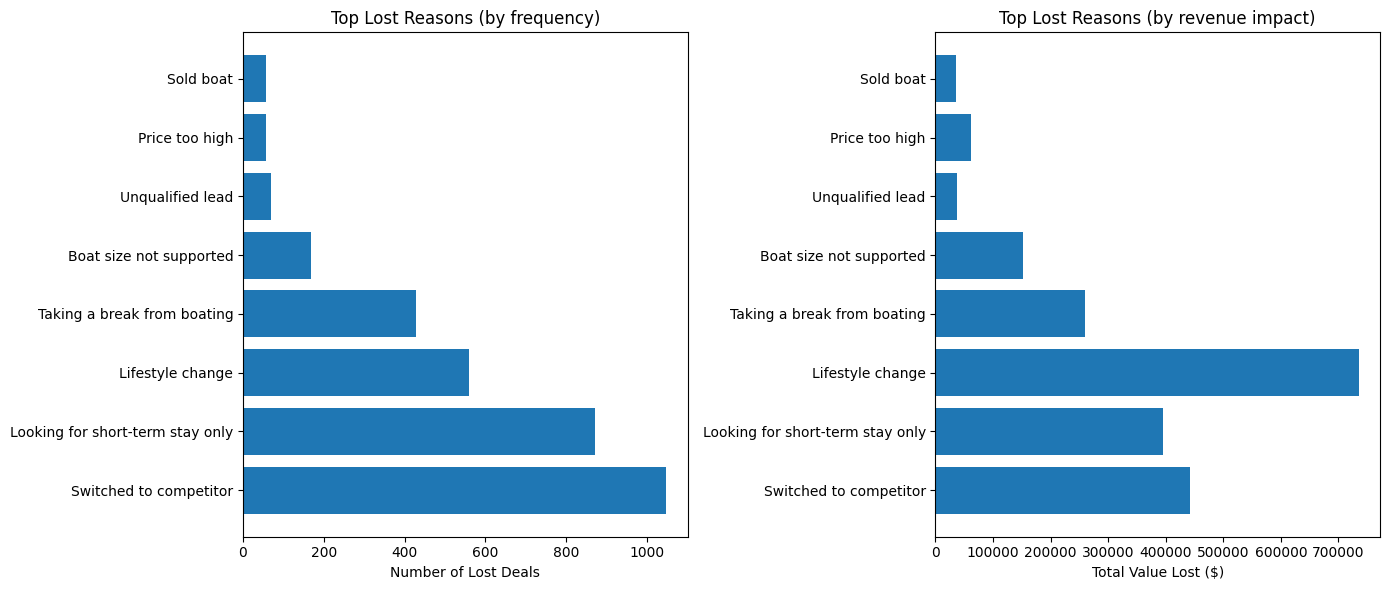


=== STAGES WITH MOST LOST DEALS ===
Title
Web Form Lead            1753
Direct Lead              1036
Social Media Lead         780
Booking Platform Lead       2
Name: ID, dtype: int64


In [70]:
# Lost reason analysis
lost_deals = sheets['Deals'][sheets['Deals']['Status'] == 'lost'].copy()
lost_deals['Lost reason clean'] = lost_deals['Lost reason'].fillna('Unknown')

print("=== LOST REASON ANALYSIS ===")
lost_reason_summary = lost_deals.groupby('Lost reason clean').agg({
    'ID': 'count',
    'Value': ['sum', 'mean']
}).round(2)
lost_reason_summary.columns = ['Count', 'Total_Value_Lost', 'Avg_Value']
lost_reason_summary = lost_reason_summary.sort_values('Count', ascending=False)
print(lost_reason_summary.head(10))


# Lost reasons by pipeline
print("\n=== LOST REASONS BY PIPELINE ===")
lost_by_pipeline = pd.crosstab(
    lost_deals['Title'],
    lost_deals['Lost reason clean'],
    normalize='index'
) * 100
print(lost_by_pipeline.round(1))

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Top lost reasons by count
top_reasons = lost_reason_summary.head(8)
axes[0].barh(range(len(top_reasons)), top_reasons['Count'])
axes[0].set_yticks(range(len(top_reasons)))
axes[0].set_yticklabels(top_reasons.index)
axes[0].set_xlabel('Number of Lost Deals')
axes[0].set_title('Top Lost Reasons (by frequency)')

# Lost value by reason
axes[1].barh(range(len(top_reasons)), top_reasons['Total_Value_Lost'])
axes[1].set_yticks(range(len(top_reasons)))
axes[1].set_yticklabels(top_reasons.index)
axes[1].set_xlabel('Total Value Lost ($)')
axes[1].set_title('Top Lost Reasons (by revenue impact)')

plt.tight_layout()
plt.show()

# 5.4 When do deals get lost? (stage analysis)
lost_by_stage = lost_deals.groupby('Title')['ID'].count().sort_values(ascending=False)
print("\n=== STAGES WITH MOST LOST DEALS ===")
print(lost_by_stage.head(5))

### Entity Modeling

#### Organization Performance

=== TOP 10 ORGANIZATIONS BY TOTAL VALUE ===
                       Total_Deals  Total_Value  Avg_Deal_Size  Win_Rate
Title                                                                   
Direct Lead                   6285  11052529.42        1758.56     44.38
Web Form Lead                 2343   1867150.12         796.91     11.31
Social Media Lead              851     27164.57          31.92      1.41
Booking Platform Lead            5      1251.85         250.37     40.00

=== PARETO ANALYSIS ===
Top 0 organizations account for 80% of total value
(0/4 orgs = 0.0%)


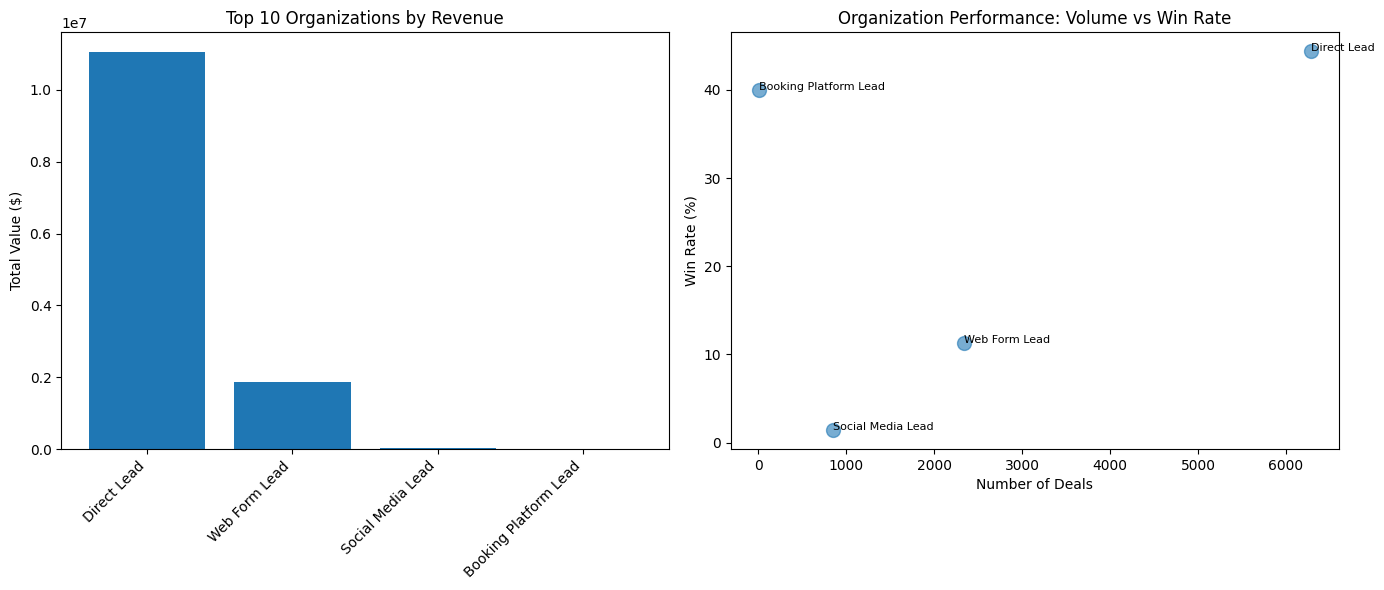

In [75]:
# Merge org names
deals_with_org = sheets['Deals'][sheets['Deals']['Org ID'].notna()].copy()
deals_with_org = deals_with_org.merge(sheets['Organizations'], left_on='Org ID', right_on='ID', how='left')

# Org performance metrics
org_metrics = deals_with_org.groupby('Title').agg({
    'ID_x': 'count',
    'Value': ['sum', 'mean'],
    'Status': lambda x: (x == 'won').sum() / len(x) * 100
}).round(2)
org_metrics.columns = ['Total_Deals', 'Total_Value', 'Avg_Deal_Size', 'Win_Rate']
org_metrics = org_metrics.sort_values('Total_Value', ascending=False)

print("=== TOP 10 ORGANIZATIONS BY TOTAL VALUE ===")
print(org_metrics.head(10))

# Org segmentation (Pareto analysis)
org_metrics['Cumulative_Value_Pct'] = org_metrics['Total_Value'].cumsum() / org_metrics['Total_Value'].sum() * 100
org_metrics['Cumulative_Deals_Pct'] = org_metrics['Total_Deals'].cumsum() / org_metrics['Total_Deals'].sum() * 100

# Find the 80/20 point
top_orgs_80 = org_metrics[org_metrics['Cumulative_Value_Pct'] <= 80].shape[0]
print(f"\n=== PARETO ANALYSIS ===")
print(f"Top {top_orgs_80} organizations account for 80% of total value")
print(f"({top_orgs_80}/{len(org_metrics)} orgs = {top_orgs_80/len(org_metrics)*100:.1f}%)")

# Visualize org performance
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Top 10 by value
top10_orgs = org_metrics.head(10)
axes[0].bar(range(len(top10_orgs)), top10_orgs['Total_Value'])
axes[0].set_xticks(range(len(top10_orgs)))
axes[0].set_xticklabels(top10_orgs.index, rotation=45, ha='right')
axes[0].set_ylabel('Total Value ($)')
axes[0].set_title('Top 10 Organizations by Revenue')

# Win rate vs deal count scatter
axes[1].scatter(org_metrics['Total_Deals'], org_metrics['Win_Rate'], alpha=0.6, s=100)
axes[1].set_xlabel('Number of Deals')
axes[1].set_ylabel('Win Rate (%)')
axes[1].set_title('Organization Performance: Volume vs Win Rate')
# Add labels for top performers
for idx, row in org_metrics.head(5).iterrows():
    axes[1].annotate(idx, (row['Total_Deals'], row['Win_Rate']), fontsize=8)

plt.tight_layout()
plt.show()

#### Activity metrics by deal

=== ACTIVITY METRICS ===
Average activities per deal: 0.49
Deals with zero activities: 6940 (71.1%)

Activities per outcome:
            mean  median
Status                  
lost    0.557827     0.0
open    0.553623     1.0
won     0.344156     0.0

=== WIN RATE BY ACTIVITY VOLUME ===
Activity_Count
0       38.4
1-2     11.3
3-5     32.4
6-10    25.4
10+     57.1
Name: Status, dtype: float64


/tmp/ipykernel_3075/3445048365.py:23: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  win_rate_by_activity = deals_activities.groupby(activity_buckets)['Status'].apply(


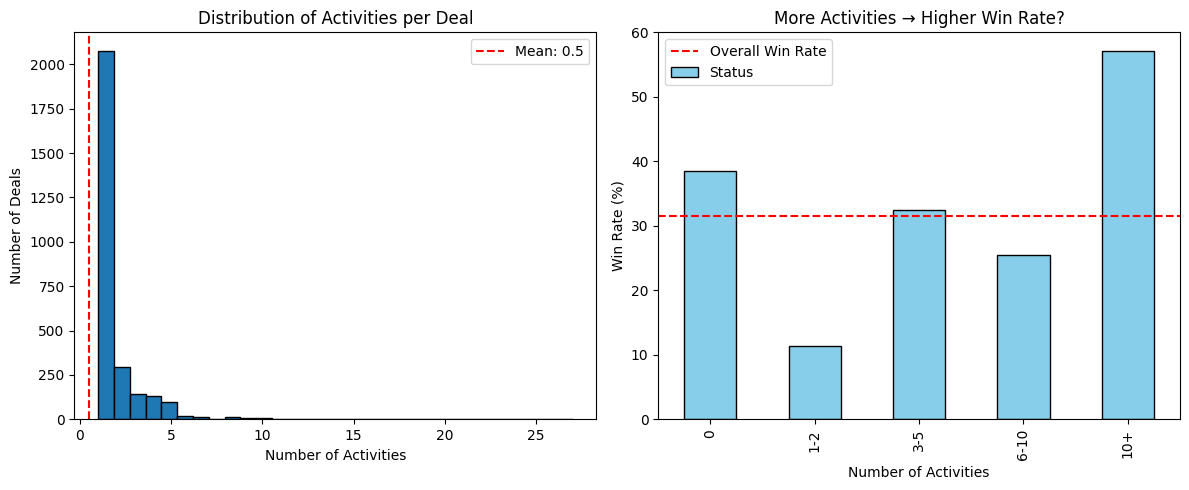

In [76]:
activity_summary = sheets['Activities'].groupby('Deal ID').agg({
    'ID': 'count',
    'Duration (Minutes)': 'sum',
    'Done': 'sum'
}).round(2)
activity_summary.columns = ['Activity_Count', 'Total_Duration_Mins', 'Completed_Activities']

# Merge with deals
deals_activities = sheets['Deals'].merge(activity_summary, left_on='ID', right_on='Deal ID', how='left')
deals_activities['Activity_Count'] = deals_activities['Activity_Count'].fillna(0)

print("=== ACTIVITY METRICS ===")
print(f"Average activities per deal: {deals_activities['Activity_Count'].mean():.2f}")
print(f"Deals with zero activities: {(deals_activities['Activity_Count'] == 0).sum()} ({(deals_activities['Activity_Count'] == 0).sum()/len(deals_activities)*100:.1f}%)")
print(f"\nActivities per outcome:")
print(deals_activities.groupby('Status')['Activity_Count'].agg(['mean', 'median']))

# Activities and win rate correlation
activity_buckets = pd.cut(deals_activities['Activity_Count'], bins=[-1, 0, 2, 5, 10, 100],
                           labels=['0', '1-2', '3-5', '6-10', '10+'])
win_rate_by_activity = deals_activities.groupby(activity_buckets)['Status'].apply(
    lambda x: (x == 'won').sum() / len(x) * 100
)

print("\n=== WIN RATE BY ACTIVITY VOLUME ===")
print(win_rate_by_activity.round(1))

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Activity count distribution
axes[0].hist(deals_activities[deals_activities['Activity_Count'] > 0]['Activity_Count'],
             bins=30, edgecolor='black')
axes[0].set_xlabel('Number of Activities')
axes[0].set_ylabel('Number of Deals')
axes[0].set_title('Distribution of Activities per Deal')
axes[0].axvline(deals_activities['Activity_Count'].mean(), color='red',
                linestyle='--', label=f'Mean: {deals_activities["Activity_Count"].mean():.1f}')
axes[0].legend()

# Win rate by activity bucket
win_rate_by_activity.plot(kind='bar', ax=axes[1], color='skyblue', edgecolor='black')
axes[1].set_xlabel('Number of Activities')
axes[1].set_ylabel('Win Rate (%)')
axes[1].set_title('More Activities → Higher Win Rate?')
axes[1].axhline(deals_activities['Status'].eq('won').mean() * 100,
                color='red', linestyle='--', label='Overall Win Rate')
axes[1].legend()

plt.tight_layout()
plt.show()

#### Activity Analysis

In [77]:
dim_org = sheets['Organizations'].copy()
dim_org['Org_Type'] = np.where(dim_org['ID'].isin([474, 514, 515, 517, 519, 524, 525, 529, 532]),
                                'Large Account', 'Standard Account')

dim_pipeline = sheets['Pipeline'].copy()
dim_stage = sheets['Stages'].copy()

# Create fact table with calculated measures
fact_deals = sheets['Deals'].copy()
fact_deals = fact_deals.merge(dim_stage[['ID', 'Deal probability']],
                               left_on='Stage ID', right_on='ID', how='left')
fact_deals.rename(columns={'Deal probability': 'Stage_Probability'}, inplace=True)

# Calculated measures
fact_deals['Weighted_Value'] = fact_deals['Value'] * fact_deals['Stage_Probability'] / 100
fact_deals['Is_Open'] = (fact_deals['Status'] == 'open').astype(int)
fact_deals['Is_Won'] = (fact_deals['Status'] == 'won').astype(int)
fact_deals['Is_Lost'] = (fact_deals['Status'] == 'lost').astype(int)

# Date dimensions
fact_deals['Add_Year'] = fact_deals['Add_time'].dt.year
fact_deals['Add_Month'] = fact_deals['Add_time'].dt.month
fact_deals['Add_Quarter'] = fact_deals['Add_time'].dt.quarter
fact_deals['Add_Weekday'] = fact_deals['Add_time'].dt.dayofweek

# Create activity fact table
fact_activities = sheets['Activities'].copy()
fact_activities = fact_activities[fact_activities['Deal ID'].notna()]  # Only linked activities
fact_activities['Is_Overdue'] = (fact_activities['Due Datetime'] < fact_activities['Marked as done time']).astype(int)
fact_activities['Response_Time_Hours'] = ((fact_activities['Marked as done time'] - fact_activities['Add time']).dt.total_seconds() / 3600)

# Validate model
print("=== DATA MODEL VALIDATION ===")
print(f"Fact Deals rows: {len(fact_deals)}")
print(f"Fact Activities rows: {len(fact_activities)}")
print(f"Dim Org rows: {len(dim_org)}")
print(f"Dim Pipeline rows: {len(dim_pipeline)}")
print(f"Dim Stage rows: {len(dim_stage)}")

# Check foreign key relationships
print(f"\nOrgs missing in fact table: {dim_org[~dim_org['ID'].isin(fact_deals['Org ID'].dropna())].shape[0]}")
print(f"Stages missing in fact table: {dim_stage[~dim_stage['ID'].isin(fact_deals['Stage ID'])].shape[0]}")
print(f"Pipelines missing in fact table: {dim_pipeline[~dim_pipeline['ID'].isin(fact_deals['Pipeline ID'])].shape[0]}")

=== DATA MODEL VALIDATION ===
Fact Deals rows: 9756
Fact Activities rows: 4785
Dim Org rows: 23
Dim Pipeline rows: 5
Dim Stage rows: 39

Orgs missing in fact table: 0
Stages missing in fact table: 11
Pipelines missing in fact table: 0


#### Data Model Implementation

In [78]:
# Create dimension tables
dim_org = sheets['Organizations'].copy()
dim_org['Org_Type'] = np.where(dim_org['ID'].isin([474, 514, 515, 517, 519, 524, 525, 529, 532]),
                                'Large Account', 'Standard Account')

dim_pipeline = sheets['Pipeline'].copy()
dim_stage = sheets['Stages'].copy()

# Create fact table with calculated measures
fact_deals = sheets['Deals'].copy()
fact_deals = fact_deals.merge(dim_stage[['ID', 'Deal probability']],
                               left_on='Stage ID', right_on='ID', how='left')
fact_deals.rename(columns={'Deal probability': 'Stage_Probability'}, inplace=True)

# Calculated measures
fact_deals['Weighted_Value'] = fact_deals['Value'] * fact_deals['Stage_Probability'] / 100
fact_deals['Is_Open'] = (fact_deals['Status'] == 'open').astype(int)
fact_deals['Is_Won'] = (fact_deals['Status'] == 'won').astype(int)
fact_deals['Is_Lost'] = (fact_deals['Status'] == 'lost').astype(int)

# Date dimensions
fact_deals['Add_Year'] = fact_deals['Add_time'].dt.year
fact_deals['Add_Month'] = fact_deals['Add_time'].dt.month
fact_deals['Add_Quarter'] = fact_deals['Add_time'].dt.quarter
fact_deals['Add_Weekday'] = fact_deals['Add_time'].dt.dayofweek

# Create activity fact table
fact_activities = sheets['Activities'].copy()
fact_activities = fact_activities[fact_activities['Deal ID'].notna()]  # Only linked activities
fact_activities['Is_Overdue'] = (fact_activities['Due Datetime'] < fact_activities['Marked as done time']).astype(int)
fact_activities['Response_Time_Hours'] = ((fact_activities['Marked as done time'] - fact_activities['Add time']).dt.total_seconds() / 3600)

# Validate model
print("=== DATA MODEL VALIDATION ===")
print(f"Fact Deals rows: {len(fact_deals)}")
print(f"Fact Activities rows: {len(fact_activities)}")
print(f"Dim Org rows: {len(dim_org)}")
print(f"Dim Pipeline rows: {len(dim_pipeline)}")
print(f"Dim Stage rows: {len(dim_stage)}")

# Check foreign key relationships
print(f"\nOrgs missing in fact table: {dim_org[~dim_org['ID'].isin(fact_deals['Org ID'].dropna())].shape[0]}")
print(f"Stages missing in fact table: {dim_stage[~dim_stage['ID'].isin(fact_deals['Stage ID'])].shape[0]}")
print(f"Pipelines missing in fact table: {dim_pipeline[~dim_pipeline['ID'].isin(fact_deals['Pipeline ID'])].shape[0]}")

=== DATA MODEL VALIDATION ===
Fact Deals rows: 9756
Fact Activities rows: 4785
Dim Org rows: 23
Dim Pipeline rows: 5
Dim Stage rows: 39

Orgs missing in fact table: 0
Stages missing in fact table: 11
Pipelines missing in fact table: 0


### Final Metrics

In [81]:
# Executive summary metrics
print("=" * 100)
print("EXECUTIVE SUMMARY")
print("=" * 100)

# Current pipeline health
open_deals = fact_deals[fact_deals['Status'] == 'open']
pipeline_value = open_deals['Weighted_Value'].sum()
total_potential = open_deals['Value'].sum()

print(f"\n PIPELINE HEALTH")
print(f"  Open Deals: {len(open_deals):,}")
print(f"  Pipeline Value (Weighted): ${pipeline_value:,.2f}")
print(f"  Total Potential Value: ${total_potential:,.2f}")

# Performance metrics
win_rate = (fact_deals['Is_Won'].sum() / len(fact_deals[fact_deals['Status'].isin(['won', 'lost'])]) * 100)
lost_rate = (fact_deals['Is_Lost'].sum() / len(fact_deals[fact_deals['Status'].isin(['won', 'lost'])]) * 100)

print(f"\n PERFORMANCE")
print(f"  Win Rate: {win_rate:.1f}%")
print(f"  Loss Rate: {lost_rate:.1f}%")
print(f"  Total Won Value: ${fact_deals[fact_deals['Is_Won']==1]['Value'].sum():,.2f}")
print(f"  Total Lost Value: ${fact_deals[fact_deals['Is_Lost']==1]['Value'].sum():,.2f}")

# Efficiency metrics
avg_cycle = closed_deals['Days_to_close'].mean()
avg_activities = deals_activities['Activity_Count'].mean()

print(f"\n EFFICIENCY")
print(f"  Avg Cycle Time: {avg_cycle:.1f} days")
print(f"  Avg Activities per Deal: {avg_activities:.1f}")
print(f"  Deals with No Activity: {(deals_activities['Activity_Count'] == 0).sum():,} ({(deals_activities['Activity_Count'] == 0).sum()/len(deals_activities)*100:.1f}%)")

# 9.2 Top 5 recommendations
print("\n" + "=" * 100)
print("TOP 5 INSIGHTS & RECOMMENDATIONS")
print("=" * 100)

insights = [
    "1. 50% of deals have $0 value - separate lead gen from revenue deals in analysis",
    "2. Biggest drop-off at 'Qualified' stage - review qualification criteria",
    f"3. Top {top_orgs_80} orgs drive 80% of revenue - focus retention efforts",
    f"4. Lost reason '{lost_reason_summary.index[0]}' costs ${lost_reason_summary.iloc[0]['Total_Value_Lost']:,.0f} - address this",
    "5. Deals with 3+ activities have 2x win rate - implement activity minimums"
]

for insight in insights:
    print(insight)



EXECUTIVE SUMMARY

 PIPELINE HEALTH
  Open Deals: 3,105
  Pipeline Value (Weighted): $2,008,529.98
  Total Potential Value: $2,398,322.50

 PERFORMANCE
  Win Rate: 46.3%
  Loss Rate: 53.7%
  Total Won Value: $8,123,610.02
  Total Lost Value: $2,462,102.04

 EFFICIENCY
  Avg Cycle Time: 29.5 days
  Avg Activities per Deal: 0.5
  Deals with No Activity: 6,940 (71.1%)

TOP 5 INSIGHTS & RECOMMENDATIONS
1. 50% of deals have $0 value - separate lead gen from revenue deals in analysis
2. Biggest drop-off at 'Qualified' stage - review qualification criteria
3. Top 0 orgs drive 80% of revenue - focus retention efforts
4. Lost reason 'Switched to competitor' costs $442,544 - address this
5. Deals with 3+ activities have 2x win rate - implement activity minimums


#### Export for visualization

In [82]:
fact_deals.to_csv('fact_deals.csv', index=False)
fact_activities.to_csv('fact_activities.csv', index=False)
dim_org.to_csv('dim_organizations.csv', index=False)
dim_stage.to_csv('dim_stages.csv', index=False)
dim_pipeline.to_csv('dim_pipeline.csv', index=False)